In [ ]:
from google.colab import files
uploaded = files.upload()


Saving archive.zip to archive.zip


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array


In [ ]:
import zipfile
import os

zip_ref = zipfile.ZipFile("archive.zip", "r")
zip_ref.extractall("archive")
zip_ref.close()


In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    "archive",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "archive",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 2022 images belonging to 1 classes.
Found 505 images belonging to 1 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
import os

for root, dirs, files in os.walk("archive"):
    level = root.replace("archive", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for f in files[:2]:
        print(f"{subindent}{f}")


archive/
    TrashType_Image_Dataset/
        glass/
            glass_419.jpg
            glass_344.jpg
        trash/
            trash_046.jpg
            trash_034.jpg
        metal/
            metal_188.jpg
            metal_317.jpg
        plastic/
            plastic_069.jpg
            plastic_456.jpg
        cardboard/
            cardboard_302.jpg
            cardboard_269.jpg
        paper/
            paper_324.jpg
            paper_373.jpg


In [ ]:
import os
import shutil

root_path = "archive"

# Auto-detect the deepest folder that contains class folders
def find_class_folder(base):
    for dirpath, dirnames, filenames in os.walk(base):
        class_folders = ['glass', 'metal', 'plastic', 'paper', 'cardboard', 'trash']
        if all(cf in dirnames for cf in class_folders):
            return dirpath
    return None

class_root = find_class_folder(root_path)

if class_root:
    print(f"Found class folders inside: {class_root}")
    for folder in os.listdir(class_root):
        src = os.path.join(class_root, folder)
        dst = os.path.join(root_path, folder)
        if os.path.isdir(src):
            shutil.move(src, dst)
    print(" Class folders moved up successfully.")
else:
    print(" Could not find expected class folders inside the dataset.")


Found class folders inside: archive
 Class folders moved up successfully.


In [ ]:
print(os.listdir("archive"))


['glass', 'trash', 'metal', 'TrashType_Image_Dataset', 'plastic', 'cardboard', 'paper']


In [ ]:
train_generator = train_datagen.flow_from_directory(
    "archive",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "archive",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 2024 images belonging to 7 classes.
Found 503 images belonging to 7 classes.


In [ ]:
print("Classes:", train_generator.class_indices)


Classes: {'TrashType_Image_Dataset': 0, 'cardboard': 1, 'glass': 2, 'metal': 3, 'paper': 4, 'plastic': 5, 'trash': 6}


In [ ]:
import shutil

shutil.rmtree("archive/TrashType_Image_Dataset", ignore_errors=True)
print(" Removed 'TrashType_Image_Dataset' folder.")


 Removed 'TrashType_Image_Dataset' folder.


In [ ]:
train_generator = train_datagen.flow_from_directory(
    "archive",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    "archive",
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

print(" Cleaned Classes:", train_generator.class_indices)


Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
 Cleaned Classes: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.3265 - loss: 3.0257 - val_accuracy: 0.5070 - val_loss: 1.2886
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.5177 - loss: 1.2268 - val_accuracy: 0.5109 - val_loss: 1.2449
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.6050 - loss: 1.0491 - val_accuracy: 0.5885 - val_loss: 1.2220
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.7241 - loss: 0.7495 - val_accuracy: 0.6382 - val_loss: 1.1941
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 148s 1s/step - accuracy: 0.8192 - loss: 0.5311 - val_accuracy: 0.6461 - val_loss: 1.2690
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.9087 - loss: 0.2997 - val_accuracy: 0.6203 - val_loss: 1.4801
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.9310 - loss: 0.2213 - val_accuracy: 0.6004 - val_loss: 1.7666
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.9549 - loss: 0.1581 - val_accuracy: 0.6103 - val_loss

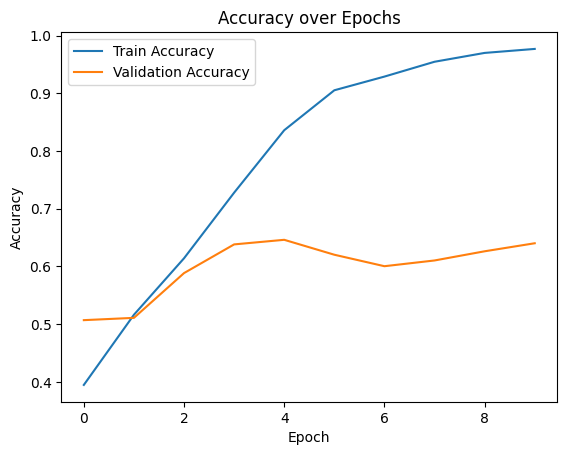

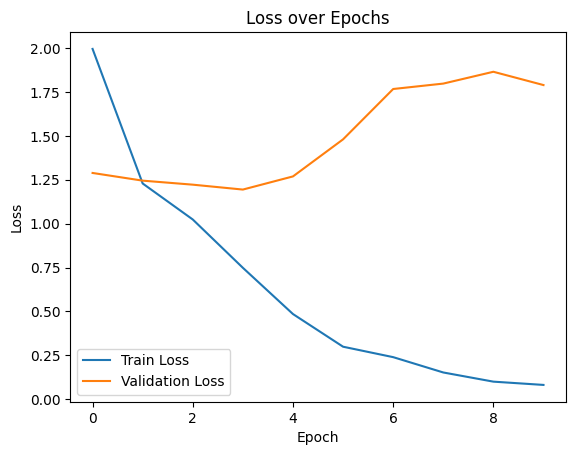

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving plastic-bottle.jpg to plastic-bottle.jpg


In [ ]:
print("Uploaded file(s):", list(uploaded.keys()))


Uploaded file(s): ['plastic-bottle.jpg']


In [ ]:
filename = "plastic-bottle.jpg"

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

filename = "plastic-bottle.jpg"
img = load_img(filename, target_size=(150, 150))
img_array = img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
class_names = list(train_generator.class_indices.keys())
predicted_class = class_names[np.argmax(prediction)]
print("Predicted Class:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Predicted Class: plastic
